In [32]:
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm
import json
import h5py
import os

import warnings
warnings.filterwarnings("ignore")


from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from DiscEvolution.diffusion import TracerDiffusion 
from DiscEvolution.planet_formation import Planets, Bitsch2015Model
from DiscEvolution.constants import *

In [11]:
def h5_to_dict(h5obj):
    out = {}
    for k, v in h5obj.items():
        if isinstance(v, h5py.Dataset):
            out[k] = v[()]          # load dataset into memory
        else:
            out[k] = h5_to_dict(v)  # recurse into group
    return out

# HJ viscous comparison 
hj_path = "/Users/james/Documents/GitHub/DiscEvolution_HJpaper_branch/James/HJ_paper_test_run_results/JulyRun/winds_mig_psi0.01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5"
    
# static
# h5_path = "/Users/james/Documents/GitHub/DiscEvolution/james/july2026/output/static/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260712_230144.h5"
# linear
# h5_path = "/Users/james/Documents/GitHub/DiscEvolution/james/july2026/output/linear/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260712_230204.h5"
# exponential
# h5_path = "/Users/james/Documents/GitHub/DiscEvolution/james/july2026/output/expo/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260713_002625.h5"
# ionization
h5_path = "/Users/james/Documents/GitHub/DiscEvolution/james/july2026/output/ionization/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260713_144007.h5"

print('\n  -------- My data ---------')
with h5py.File(h5_path, "r") as f:
    data = h5_to_dict(f)
    attrs = dict(f.attrs)

for i in data.keys():
    print(i)

print('\n -------- HJ data ---------')
with h5py.File(hj_path, "r") as f:
    hjdata = h5_to_dict(f)
    hjattrs = dict(f.attrs)

for i in hjdata.keys():
    print(i)


  -------- My data ---------
H
M_iso
M_transition
Mcs
Mes
P
R
R_dz
Rp
Sigc
Sigma_G
Sigma_dust
Sigma_grain_size
Sigma_pebble_size
Sigma_pebbles
Sigma_planetesimals
St
T
Tc
Vdrift
X_cores
X_envs
alpha_R
disk_Mass
disk_Mdot_p
disk_Mdot_star
disk_atom_gas_abund
disk_atom_ice_abund
disk_ice_lines
disk_mol_gas_abund
disk_mol_ice_abund
disk_planetesimal_atom_abund
disk_planetesimal_mol_abund
ice_lines
nu
psi_R
rho_mid
t
time_snap

 -------- HJ data ---------
M_iso
M_transition
Mcs
Mes
R
Rp
Sigc
Sigma_G
Sigma_dust
Sigma_pebble_size
Sigma_pebbles
T
Tc
Vdrift
X_cores
X_envs
disk_Mass
disk_Mdot_p
disk_Mdot_star
disk_atom_gas_abund
disk_atom_ice_abund
disk_ice_lines
disk_mol_gas_abund
disk_mol_ice_abund
ice_lines
t
time_snap


In [12]:
R = data["R"]
t = data["time_snap"]             
Sigma_g = data["Sigma_G"]          

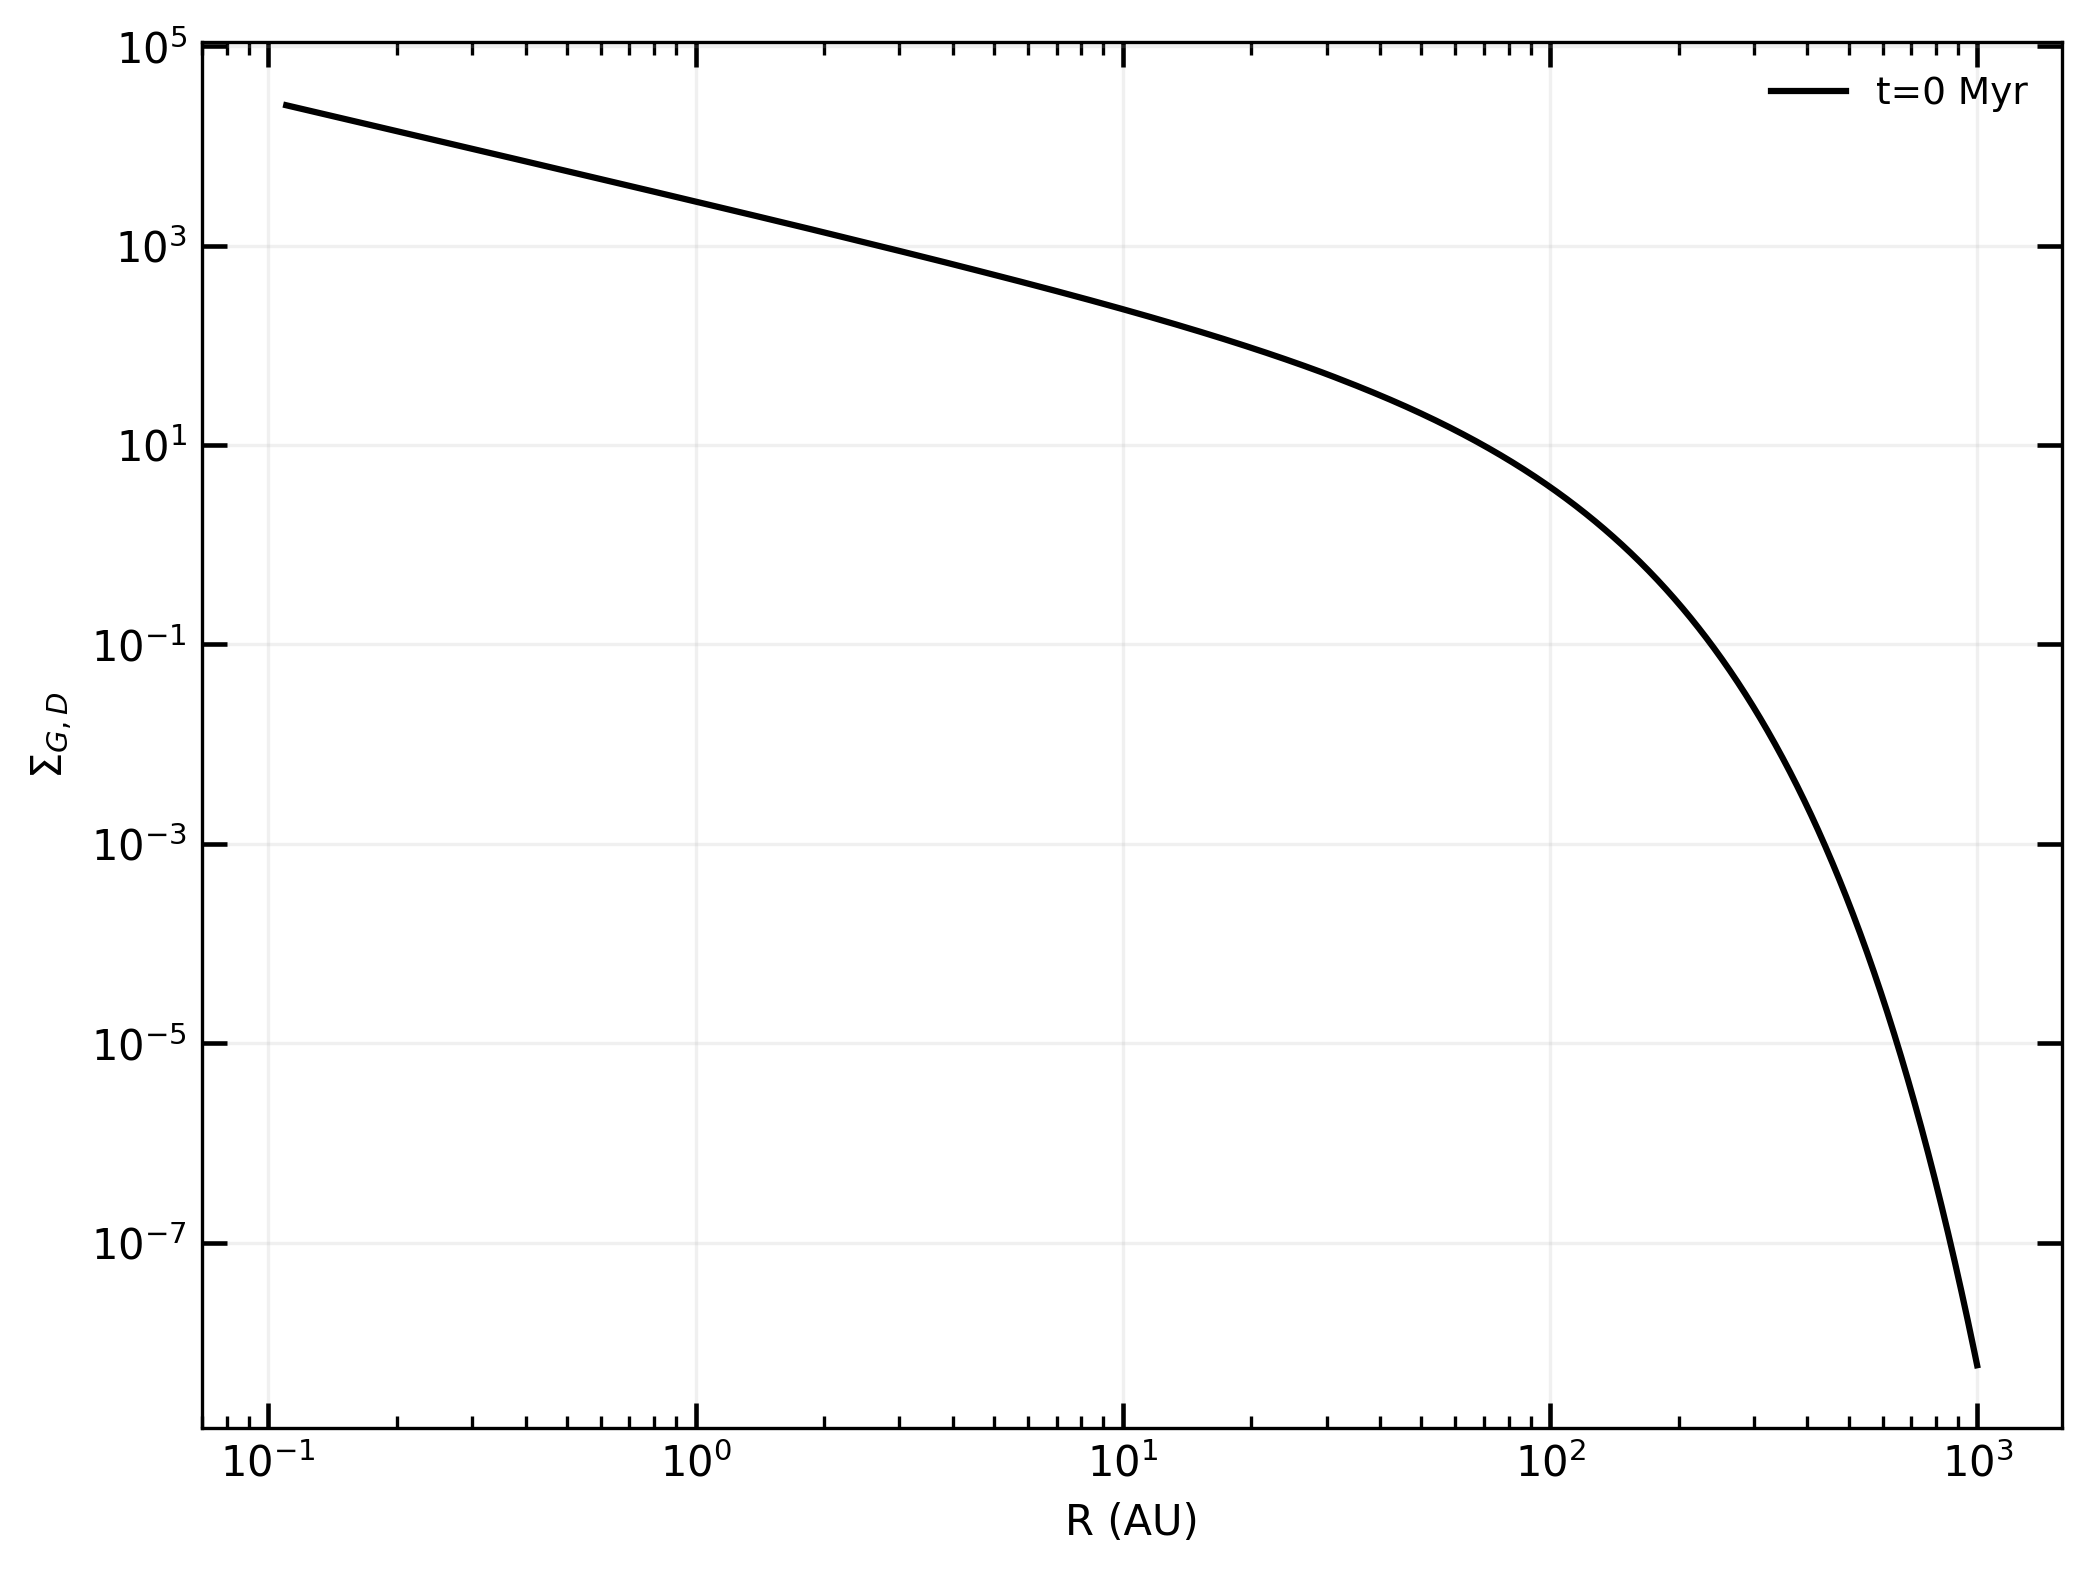

In [13]:
fig, ax = plt.subplots(figsize=(8, 6), sharex=True, dpi=300, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.loglog(R, Sigma_g[0], color='black', ls = 'solid', label=f"t={t[0]:.3g} Myr")
ax.set_ylabel(r'$\Sigma_{G,D}$')
ax.set_xlabel('R (AU)')

ax.legend(frameon=False, fontsize=9, loc="best")

In [14]:
data['t']

array([3.94021552e+01, 7.33911704e+01, 1.06981616e+02, ...,
       9.99779040e+05, 9.99872887e+05, 9.99985092e+05], shape=(22009,))

In [15]:
def nearest_indices(tsnap, times_Myr):
    """Return snapshot indices whose time_snap (Myr) is closest to each requested time."""
    times_Myr = np.atleast_1d(times_Myr)
    idx = np.array([np.abs(tsnap - tt).argmin() for tt in times_Myr])
    return np.unique(idx)


def plot_disc_values(times_Myr) -> None:
    """Plot disc profiles at the snapshots nearest to the requested times.

    times_Myr : scalar or list/array of times in Myr. The nearest available
                snapshot to each requested time is plotted. A single time is
                drawn at full opacity.
    """
    #fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    lw = 1.5

    # Radius
    R = data["R"]

    # Disc profiles are stored on the snapshot axis time_snap (Myr).
    tsnap = data["time_snap"]                 # Myr
    idx = nearest_indices(tsnap, times_Myr)   # nearest snapshot to each requested time

    #color gradient (one alpha per shown snapshot; single snapshot = full opacity)
    alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(idx))

    # Deadzone radii (one per snapshot)
    rdz = data['R_dz']

    def draw_rdz(ax):
        for a_i, i in enumerate(idx):
            ax.axvline(rdz[i], ls=':', color='red', alpha=alphas[a_i])

    # 1. Surface density: Gas and Dust
    ax = axes[0, 0]
    Sg = data['Sigma_G']
    Sd = data['Sigma_dust']
    for a_i, i in enumerate(idx):
        ax.loglog(R, Sg[i], linestyle='solid', color='C0', alpha=alphas[a_i],
                  label=rf"t={tsnap[i]:.3f} Myr", lw=lw)
        ax.loglog(R, Sd[i], linestyle='dashed', color='C1', alpha=alphas[a_i], lw=lw)
    draw_rdz(ax)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
    ax.set_title('Surface Density')
    ax.legend(fontsize=8)
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(max(np.max(Sg), np.max(Sd))))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 2. Dust-to-gas ratio (epsilon)
    ax = axes[0, 1]
    d2g = (data["Sigma_dust"] + data["Sigma_pebbles"]) / data["Sigma_G"]
    for a_i, i in enumerate(idx):
        ax.loglog(R, d2g[i], linestyle='solid', color='C0', alpha=alphas[a_i],
                  label=rf"t={tsnap[i]:.2f} Myr", lw=lw)
    draw_rdz(ax)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\epsilon$')
    ax.set_title('Total Dust/Gas Ratio')
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(np.max(d2g)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 3. Stokes number (pebble population = index 1)
    ax = axes[0, 2]
    St = data['St'][:, 1, :]                  # (n_snap, nR)
    for a_i, i in enumerate(idx):
        ax.loglog(R, St[i], linestyle='solid', color='C0', alpha=alphas[a_i],
                  label=rf"t={tsnap[i]:.2f} Myr", lw=lw)
    draw_rdz(ax)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Stokes Number')
    ax.set_title('Stokes Number (pebbles)')
    ax.set_ylim(10**(np.floor(np.log10(np.min(St)))), 10**(np.ceil(np.log10(np.max(St)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 4. Pebble size
    ax = axes[1, 0]
    a = data['Sigma_pebble_size']
    for a_i, i in enumerate(idx):
        ax.loglog(R, a[i], linestyle='solid', color='C0', alpha=alphas[a_i],
                  label=rf"t={tsnap[i]:.2f} Myr", lw=lw)
    draw_rdz(ax)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Pebble Size [cm]')
    ax.set_title('Pebble Size')
    ax.set_ylim(10**(np.floor(np.log10(np.min(a)))), 10**(np.ceil(np.log10(np.max(a)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 5. Pressure
    ax = axes[1, 1]
    P = np.abs(data['P'])
    for a_i, i in enumerate(idx):
        ax.loglog(R, P[i], linestyle='solid', color='C0', alpha=alphas[a_i],
                  label=rf"t={tsnap[i]:.2f} Myr", lw=lw)
    draw_rdz(ax)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('|P|')
    ax.set_title('Pressure')
    ax.set_ylim(10**(np.floor(np.log10(np.min(P)))), 10**(np.ceil(np.log10(np.max(P)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 6. Temperature profile
    ax = axes[1, 2]
    T = data['T']
    for a_i, i in enumerate(idx):
        ax.loglog(R, T[i], linestyle='solid', color='C0', alpha=alphas[a_i], lw=lw)
    draw_rdz(ax)

    ax.axhline(170, ls='dashed', label='170 K', color='gray', lw=1)
    ax.legend(fontsize=8)
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('T [K]')
    ax.set_title('Temperature Profile')
    ax.set_ylim(10**(np.floor(np.log10(np.min(T)))), 2e3)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    plt.suptitle('Disc Values ', fontsize=14)
    plt.tight_layout()
    #savefig('disc_values.png')
    plt.show()

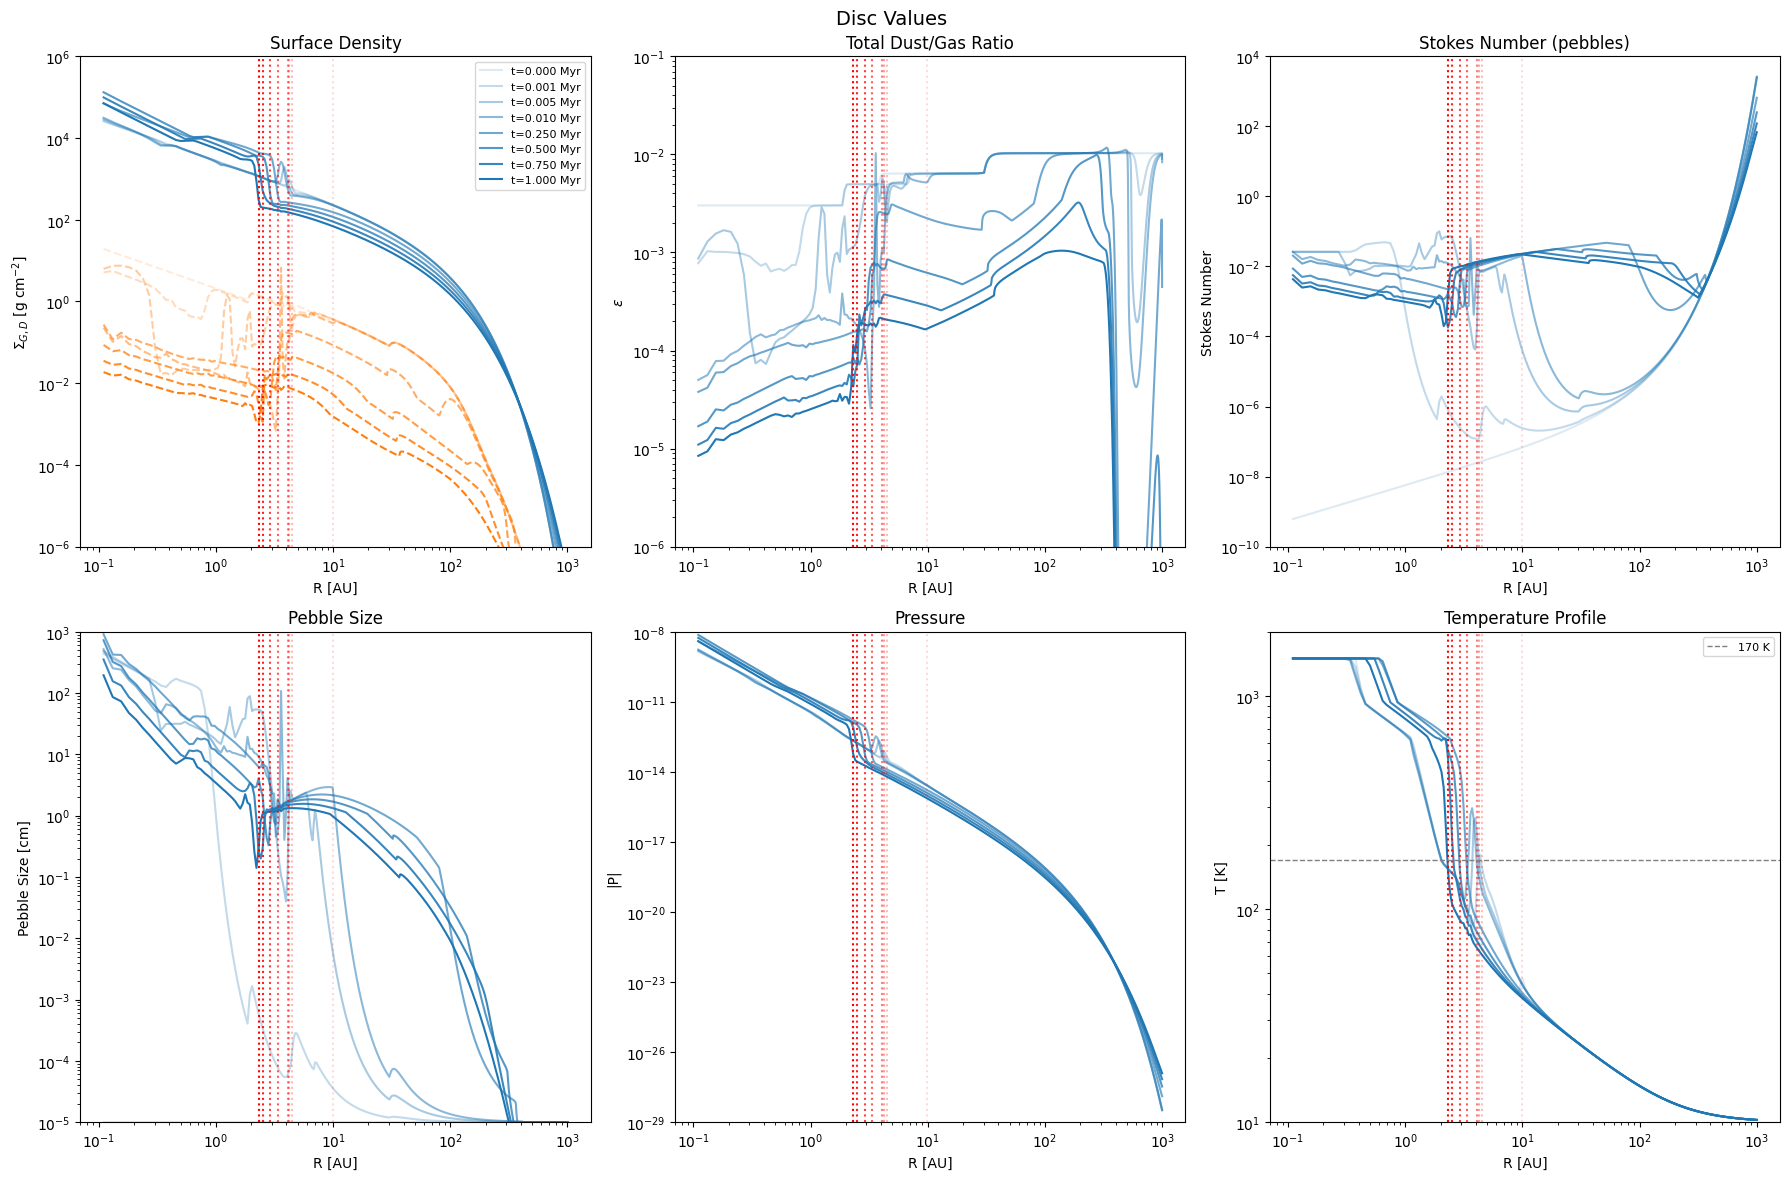

In [16]:
plot_disc_values(times_Myr=data['time_snap'])
#plot_disc_values(times_Myr=0.0)

In [17]:
hjdata['Rp']

{'0': array([0.99999674, 0.99999348, 0.99999022, ..., 0.36978686, 0.36972774,
        0.36966861], shape=(24487,)),
 '1': array([1.99999002, 1.99998002, 1.99997001, ..., 1.16993966, 1.16990485,
        1.16987004], shape=(24487,)),
 '10': array([29.99998793, 29.99997584, 29.99996374, ..., 25.41801506,
        25.41799806, 25.41798106], shape=(24487,)),
 '2': array([2.99998965, 2.99997922, 2.99996872, ..., 1.46686979, 1.46683666,
        1.46680354], shape=(24487,)),
 '3': array([3.99998439, 3.99996876, 3.99995311, ..., 3.38674558, 3.38672373,
        3.38670188], shape=(24487,)),
 '4': array([4.99998299, 4.99996595, 4.9999489 , ..., 3.89274189, 3.89272112,
        3.89270035], shape=(24487,)),
 '5': array([6.99998255, 6.99996509, 6.99994761, ..., 5.48804875, 5.4880311 ,
        5.48801345], shape=(24487,)),
 '6': array([9.99998315, 9.99996628, 9.99994939, ..., 7.80745319, 7.80743669,
        7.8074202 ], shape=(24487,)),
 '7': array([14.99998448, 14.99996895, 14.9999534 , ..., 11.78303

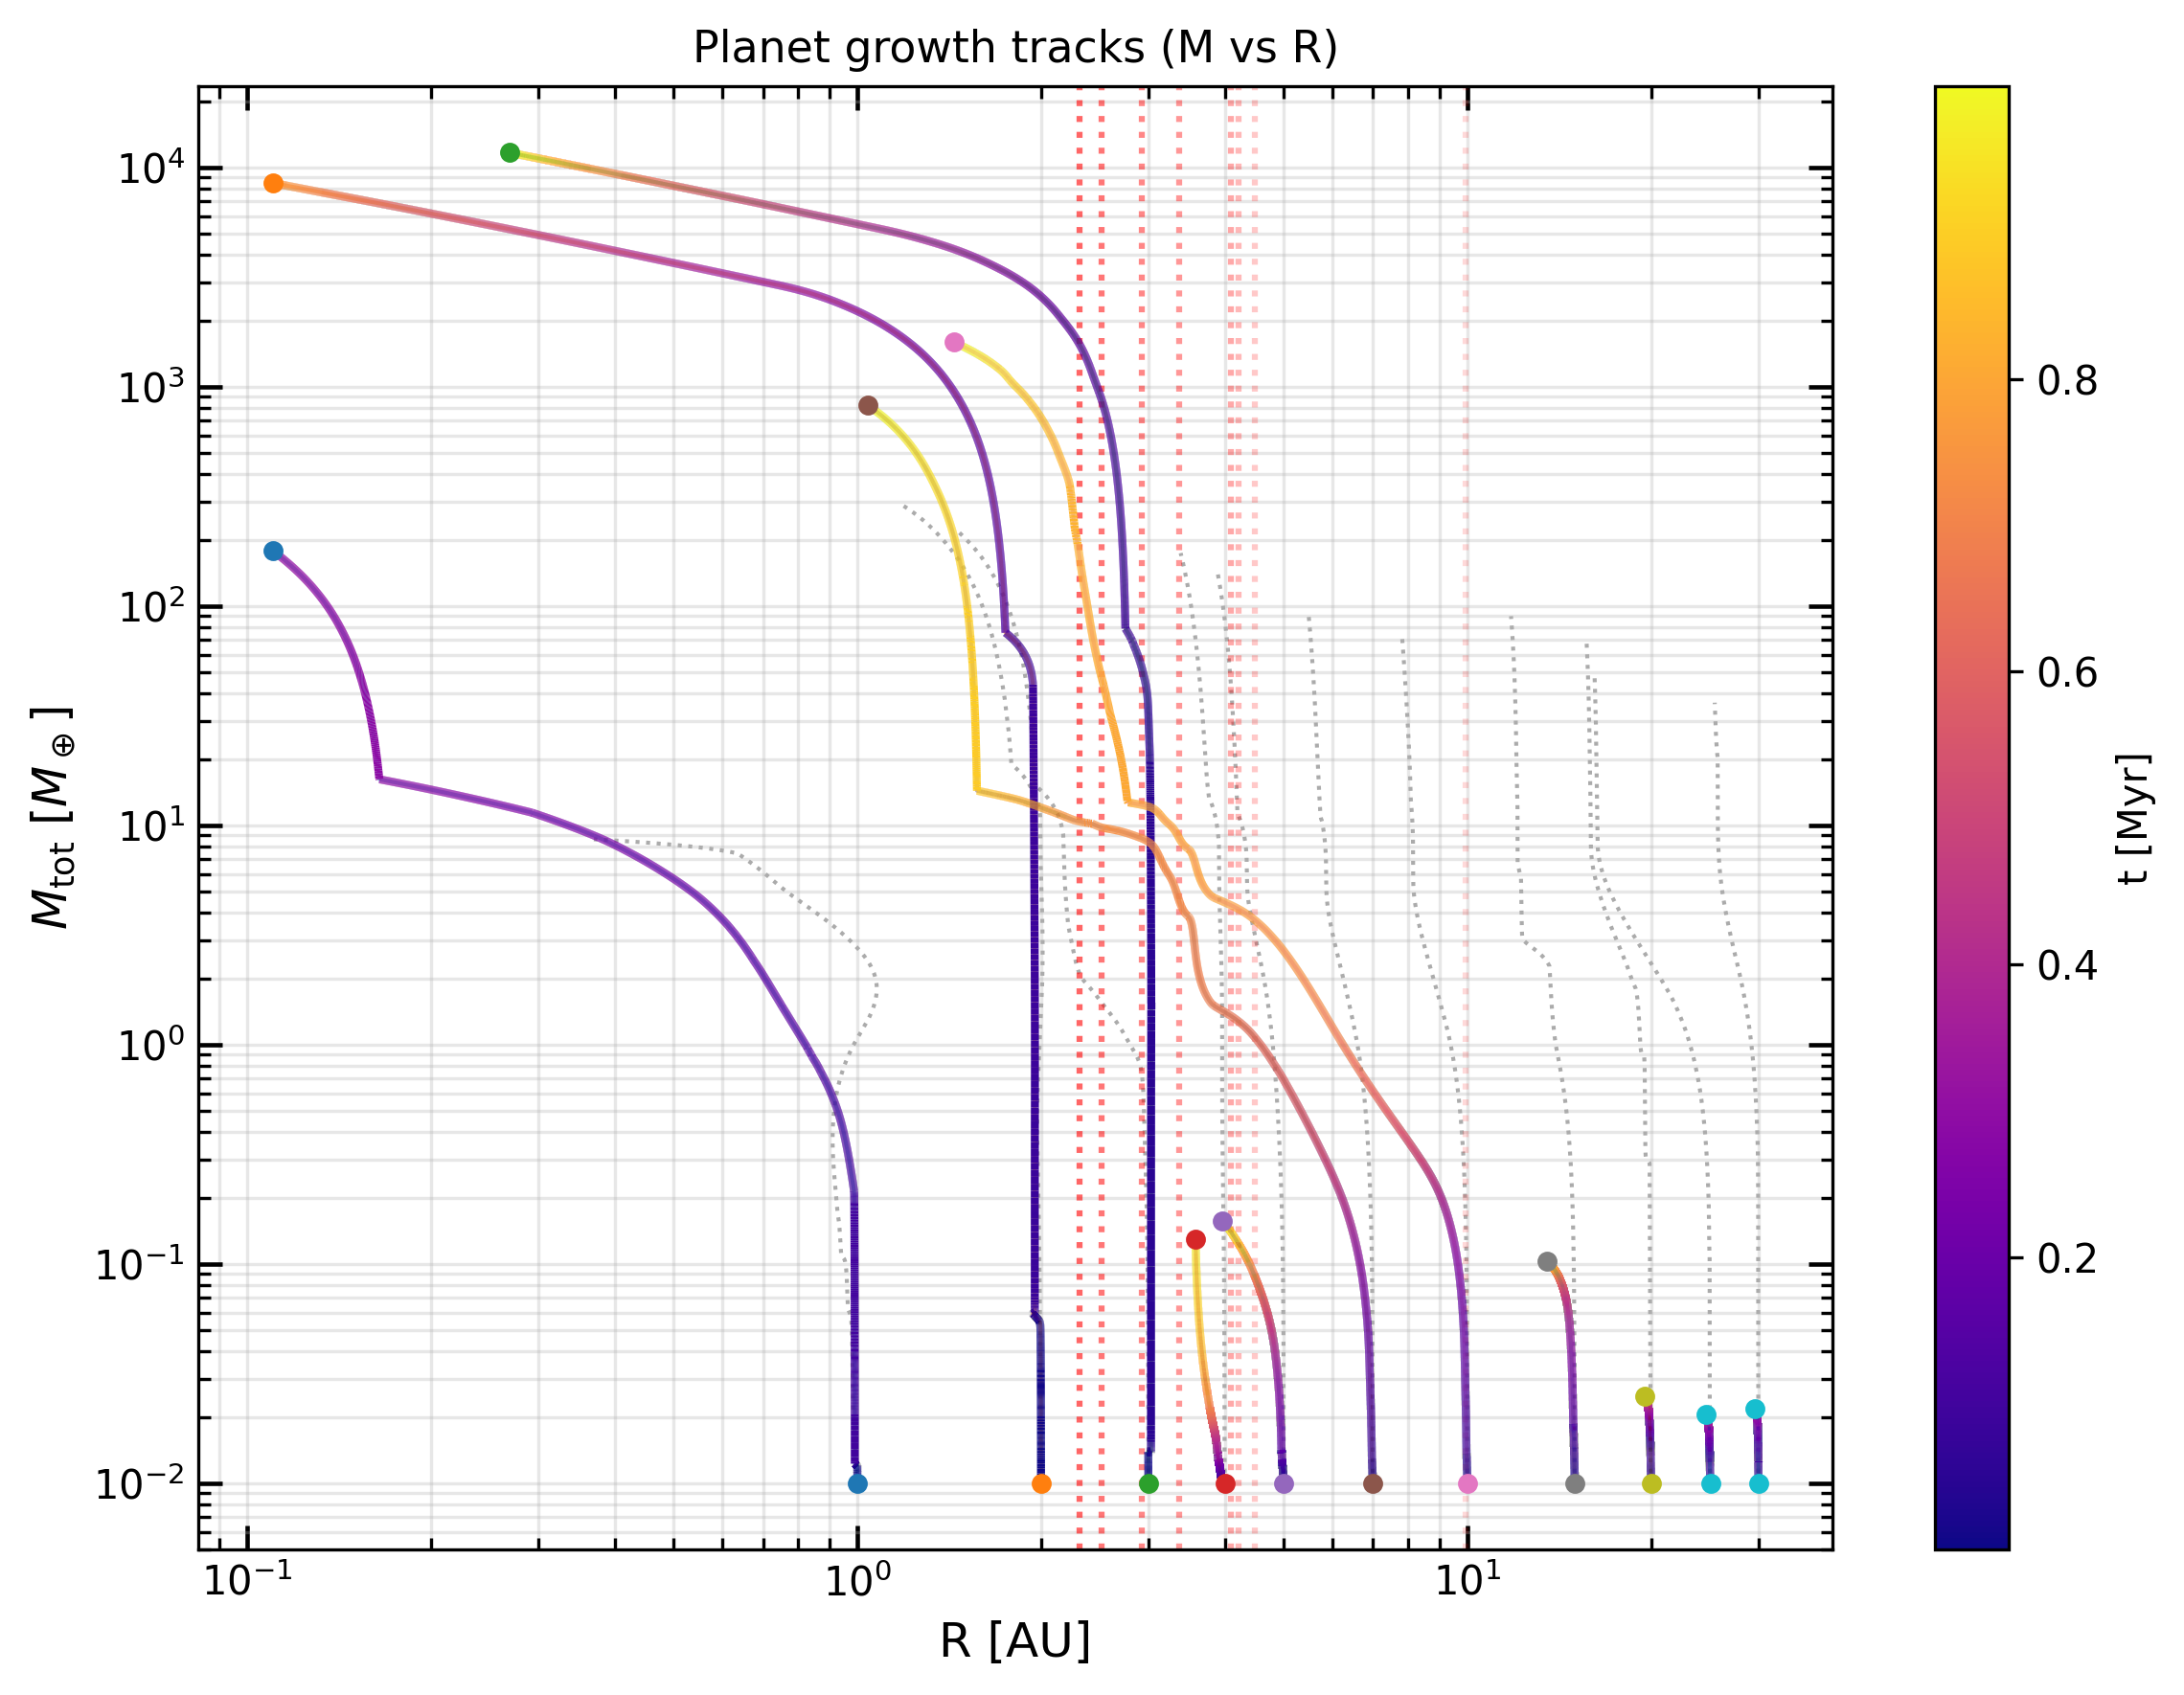

In [18]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

# Rdz lines
rdz = data['R_dz']
rdz_alphas = np.linspace(0.15, 0.6, len(rdz))
for i in range(len(rdz)):
    ax.axvline(rdz[i], ls=':', color='red', alpha=rdz_alphas[i])

# Planet arrays are keyed by str(index) and share the fine time axis data["t"] (years).
planet_ids = sorted(data["Rp"].keys(), key=int)

t_yr = np.asarray(data["t"])
t_Myr = t_yr / 1e6
norm = Normalize(vmin=t_Myr[0], vmax=t_Myr[-1])
colors = plt.cm.tab10(np.linspace(0, 1, max(len(planet_ids), 1)))

for ci, pid in enumerate(planet_ids):
    R_track    = np.asarray(data["Rp"][pid])
    Mtot_track = np.asarray(data["Mcs"][pid]) + np.asarray(data["Mes"][pid]) # Mcore + Menveloppe

    label = f'Planet {pid} ({Mtot_track[0]:.2f} M⊕)'

    # Base-colour connecting line so every track is always visible
    ax.plot(R_track, Mtot_track, '-', color=colors[ci], lw=1.0, alpha=0.5, zorder=2, label=label)

    # Time-coloured line on top
    points = np.array([R_track, Mtot_track]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='plasma', norm=norm, linewidth=2, zorder=3)
    lc.set_array(t_Myr[:-1])
    ax.add_collection(lc)

    ax.plot(R_track[0],  Mtot_track[0],  '.', color=colors[ci], ms=8,  zorder=5)
    ax.plot(R_track[-1], Mtot_track[-1], '.', color=colors[ci], ms=8, zorder=5)

sm = cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='t [Myr]')

ax.autoscale()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('R [AU]', fontsize=12)
ax.set_ylabel(r'$M_{\rm tot}$ [$M_\oplus$]', fontsize=12)
ax.set_title('Planet growth tracks (M vs R)', fontsize=11)

# HJ data comparison
hjplanet_ids = sorted(hjdata["Rp"].keys(), key=int)
t_yr = np.asarray(hjdata["t"])
t_Myr = t_yr / 1e6

for ci, pid in enumerate(hjplanet_ids):
    R_track    = np.asarray(hjdata["Rp"][pid])
    Mtot_track = np.asarray(hjdata["Mcs"][pid]) + np.asarray(hjdata["Mes"][pid]) # Mcore + Menveloppe
    ax.plot(R_track, Mtot_track, ':', color='black', lw=1.0, alpha=0.33, zorder=-2)

ax.grid(True, which='both', alpha=0.3)
# ax.legend(frameon=False, fontsize=8, loc="best")    

plt.tight_layout()
# savefig('planet_MR_tracks.png')
plt.show()

In [28]:
# xe Newton Solver 
def xe(n, zeta, xe_previous=None):
    """ 
    Compute the ionization fraction at a each radius. Return xe array. 
        """

    T = self._T 
    xe = np.zeros_like(T, dtype=float)

    beta_d = 2.0 * 1e-6 * (T**-0.5)      # cm^3/s
    beta_r = 3.0 * 1e-11 * (T**-0.5)     # cm^3/s
    beta_t = 3.0 * 1e-9                 # cm^3/s
    xm = 0.0011                         # Metal fraction 

    # --------- Newton in log-space --------
    # Coefficients + constant  ->  A(xe**3) + B(xe**2) + C(xe) + D = 0
    B = (beta_t / beta_d) * xm
    C = (-zeta) / (beta_d * n)
    D = (-zeta * beta_t * xm) / (beta_d * beta_r * n)

    active = zeta > 0.0                 # zeta = 0 gives xe = 0
    if not np.any(active):              
        return xe                       # Fast solution if not ionized anywhere

    Ba = B[active]
    Ca = C[active]
    Da = D[active]

    # Bracket the positive solution in log10(xe)
    y_lower = np.full_like(Ba, -40.0)
    y_upper = np.zeros_like(Ba)

    # Initial guess
    if xe_previous is not None:
        previous = np.asarray(xe_previous)[active]
        y = np.log10(np.clip(previous, 1.0e-40, 1.0))
    else:
        # Use the two limiting ionization estimates
        xe_molecular = np.sqrt(
            zeta[active] / (beta_d[active] * n[active])
        )

        xe_metal = np.sqrt(
            zeta[active] / (beta_r[active] * n[active])
        )

        # Geometric mean of the limiting estimates
        y = 0.5 * (
            np.log10(xe_molecular)
            + np.log10(xe_metal)
        )

        y = np.clip(y, y_lower, y_upper)

    ln10 = np.log(10.0)

    for _ in range(20):
        x = 10.0**y

        f = x**3 + Ba*x**2 + Ca*x + Da
        fp = 3.0*x**2 + 2.0*Ba*x + Ca

        # Update the bracket using the current point
        y_upper = np.where(f > 0.0, y, y_upper)
        y_lower = np.where(f <= 0.0, y, y_lower)

        derivative_log = ln10 * x * fp

        with np.errstate(divide="ignore", invalid="ignore"):
            y_newton = y - f / derivative_log

        # Reject unsafe Newton steps
        unsafe = (
            ~np.isfinite(y_newton)
            | (np.abs(derivative_log) < 1.0e-300)
            | (y_newton <= y_lower)
            | (y_newton >= y_upper)
        )

        y_bisection = 0.5 * (y_lower + y_upper)

        y_new = np.where(
            unsafe,
            y_bisection,
            y_newton
        )

        if np.max(np.abs(y_new - y)) < 1.0e-12:
            y = y_new
            break

        y = y_new

    xe_active = 10.0**y

    # Verify the solutions
    residual = np.abs(
        xe_active**3
        + Ba*xe_active**2
        + Ca*xe_active
        + Da
    )

    scale = (
        np.abs(xe_active**3)
        + np.abs(Ba*xe_active**2)
        + np.abs(Ca*xe_active)
        + np.abs(Da)
    )

    valid = (
        np.isfinite(xe_active)
        & (xe_active > 0.0)
        & (
            residual
            <= 1.0e-8 * np.maximum(scale, 1.0e-300)
        )
    )

    xe[active] = xe_active

    return xe

In [29]:
def zeta_CR(Sigma):
    zeta_0 = 1e-17        # cosmic-ray ionization rate [1/s] (Spitzer & Tomasko, 1968)
    Sigma_0 = 96.0        # CR attenuation length [g/cm^2] (Spitzer & Tomasko, 1968)

    zeta = (zeta_0/2.0) * np.exp(-(Sigma)/(Sigma_0)) # Sigma passed is already in cgs so ok
    
    return zeta #cgs

In [44]:
T = data['T']
H = data['H']
zeta = zeta_CR(Sigma_g)
rho = Sigma_g / (np.sqrt(2*np.pi) * H * AU)   # g/cm^3
n = rho / (2.4 * m_H)

In [64]:
zeta[0]

array([7.67100482e-134, 1.07796843e-114, 6.38730387e-100, 2.76060070e-088,
       5.87290229e-079, 2.29693667e-071, 4.19940974e-065, 7.05523450e-060,
       1.79449430e-055, 1.00564936e-051, 1.65357893e-048, 9.95786368e-046,
       2.61300617e-043, 3.42906605e-041, 2.51300650e-039, 1.12445591e-037,
       3.30390418e-036, 6.76759272e-035, 1.01551533e-033, 1.16341562e-032,
       1.05352742e-031, 7.76497868e-031, 4.77549626e-030, 2.50321453e-029,
       1.13889592e-028, 4.56864151e-028, 1.63794907e-027, 5.31060593e-027,
       1.57319929e-026, 4.29663437e-026, 1.09046491e-025, 2.58976240e-025,
       5.79098002e-025, 1.22607104e-024, 2.51362249e-024, 4.87695724e-024,
       8.99211340e-024, 1.59557008e-023, 2.73345709e-023, 4.53400117e-023,
       7.30007482e-023, 1.14351966e-022, 1.74634443e-022, 2.60496476e-022,
       3.80189816e-022, 5.43752301e-022, 7.63167459e-022, 1.05249477e-021,
       1.42796654e-021, 1.90805857e-021, 2.51359025e-021, 3.26810154e-021,
       4.19921786e-021, 5

In [58]:
beta_d = 2.0 * 1e-6 * (T**-0.5)      # cm^3/s
beta_r = 3.0 * 1e-11 * (T**-0.5)     # cm^3/s
beta_t = 3.0 * 1e-9                 # cm^3/s
xm = 0.0011                         # Metal fraction 

B = (beta_t / beta_d) * xm
C = (-zeta) / (beta_d * n)
D = (-zeta * beta_t * xm) / (beta_d * beta_r * n)

# snapshot, radius index
Bb = B[5,550]
Cc = C[5,550]
Dd = D[5,550]

In [59]:
def cubic(x,B,C,D):
    return x**3 + B*x**2 + C*x + D

In [79]:
x_axis = np.logspace(-20,0,10000, dtype=float)

y_axis = cubic (x_axis, Bb, Cc, Dd)
y = y_axis[1:-1] - y_axis[0:-2]
np.any(y > 0.0)


np.True_

(-1e-07, 1e-07)

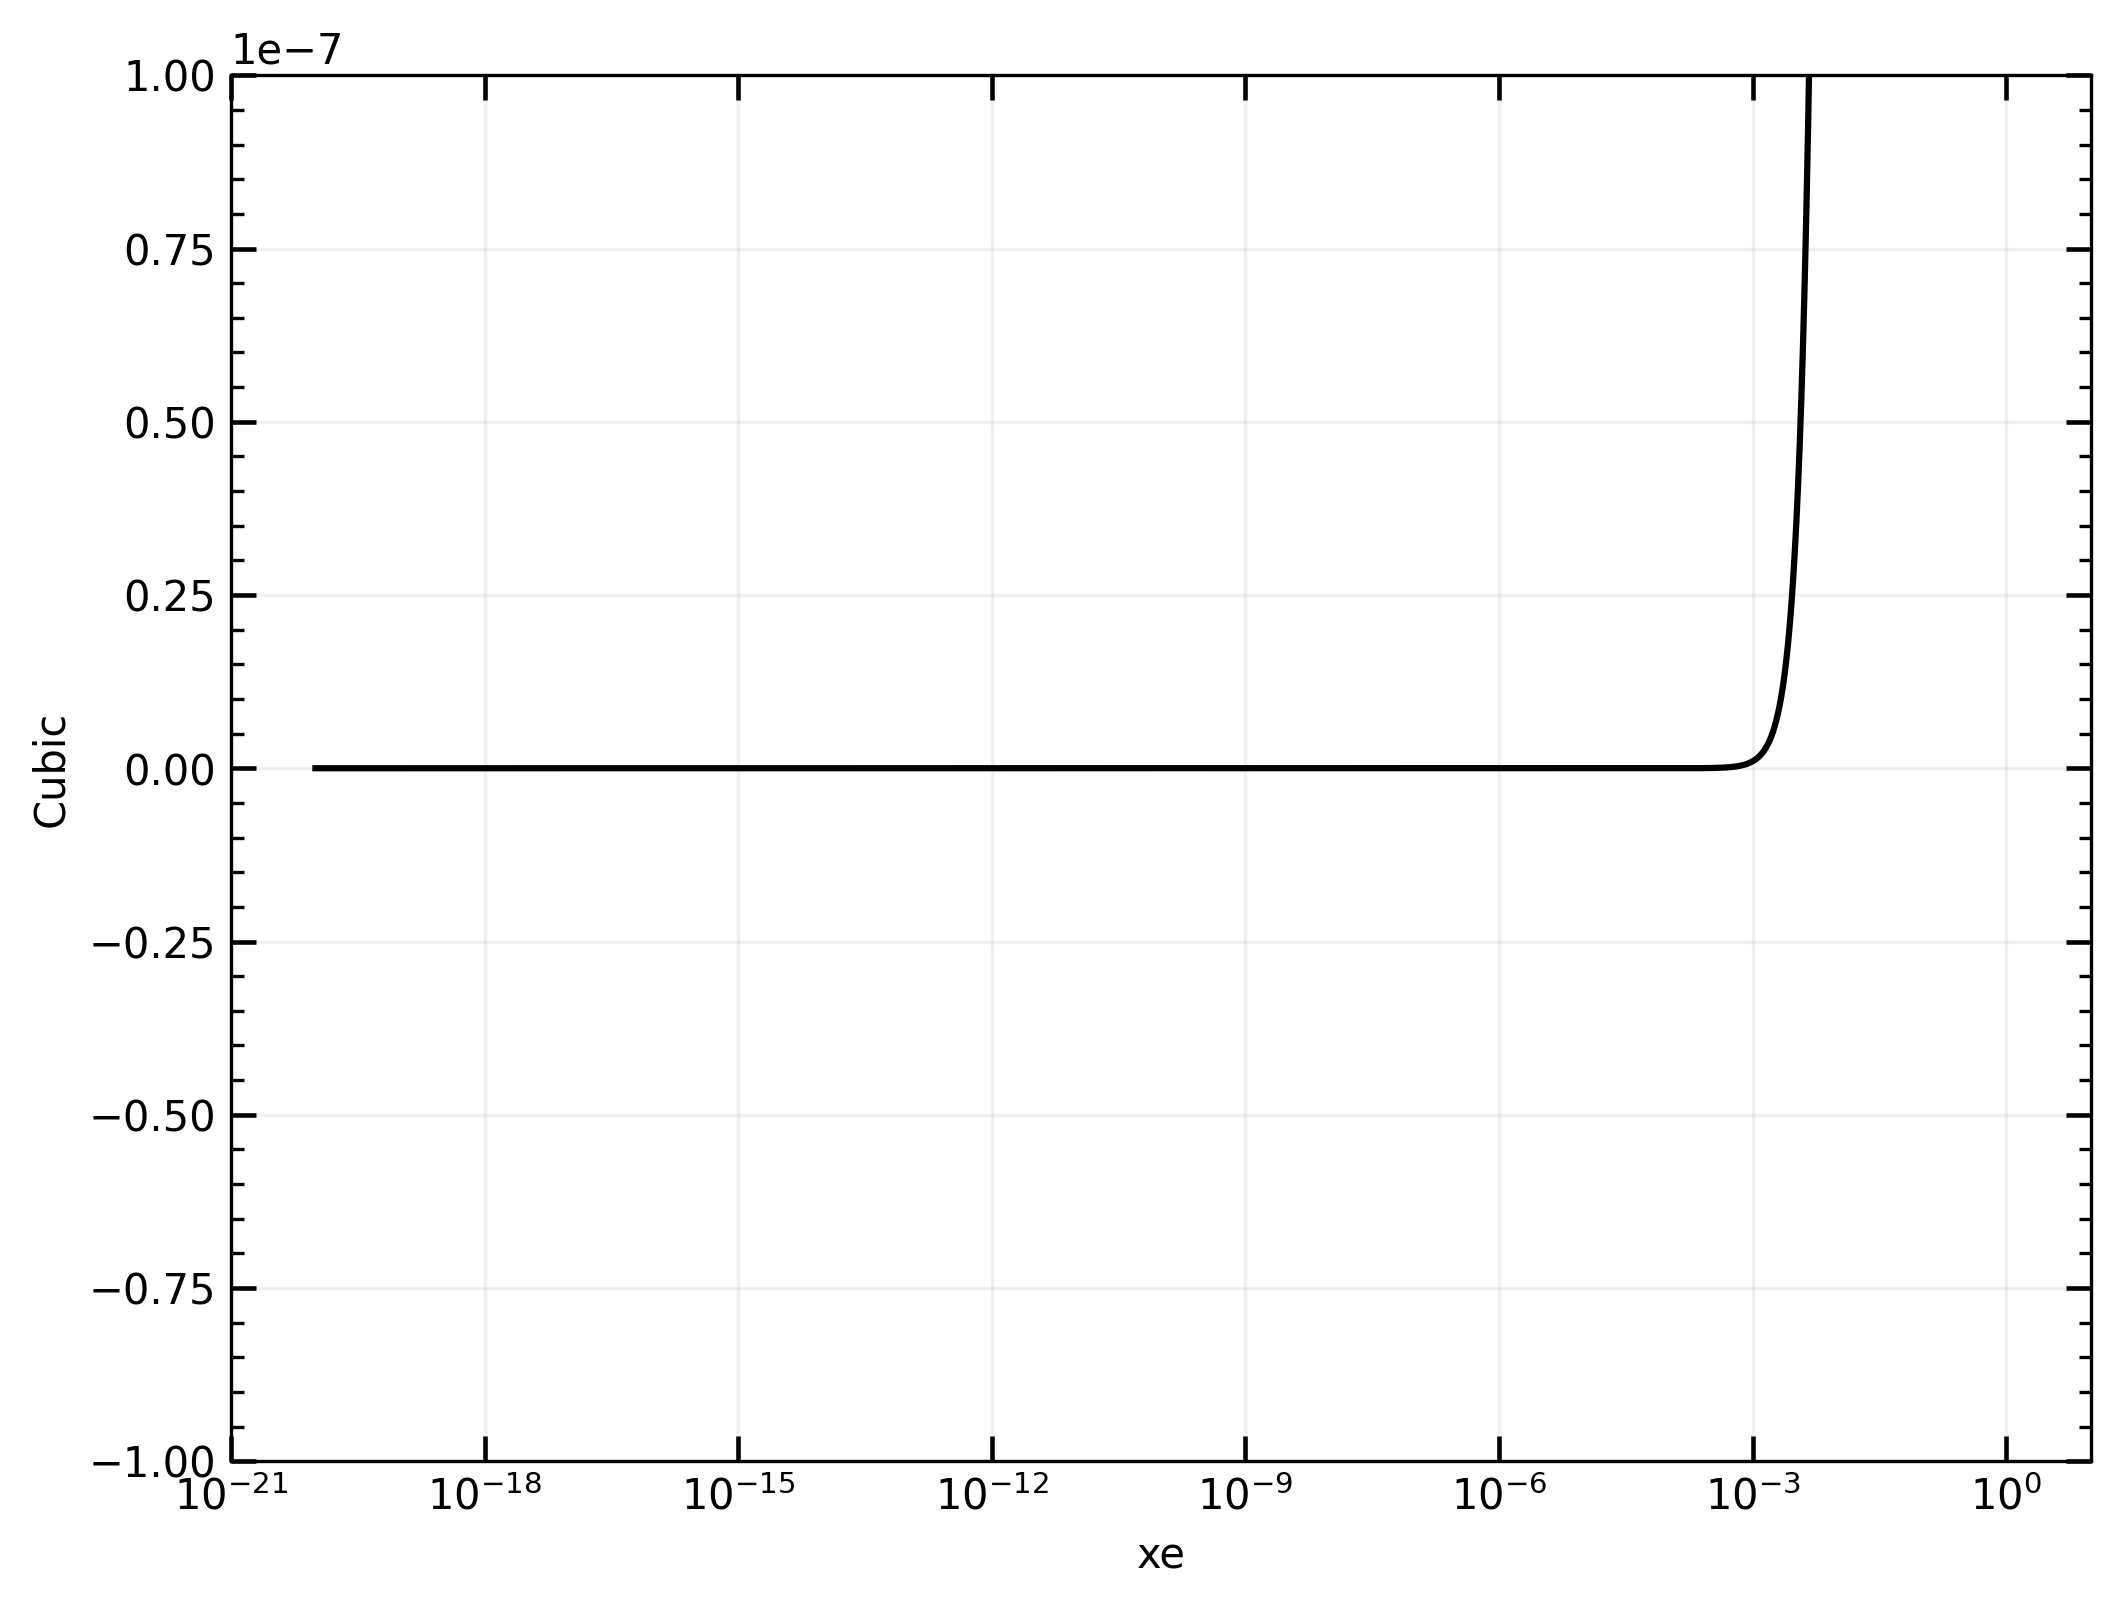

In [80]:
fig, ax = plt.subplots(figsize=(8, 6), sharex=True, dpi=300, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.semilogx(x_axis, y_axis, color='black', ls = 'solid')
ax.set_ylabel(r'Cubic')
ax.set_xlabel('xe')
#ax.set_xlim(1e-2,1)
ax.set_ylim(-0.0000001,0.0000001)

#ax.legend(frameon=False, fontsize=9, loc="best")